In [26]:
import numpy as np
import utils.data as data

from os import PathLike
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.functional as TF

from tqdm import tqdm

mpl.rcParams["figure.dpi"] = 300

dataset = data.MalwareDataset()

labels = np.array([label for _, label in dataset])
n_mal = len(labels[labels == 1])
n_ben = len(labels[labels == 0])

mal_weight = n_mal / len(dataset)
ben_weight = n_ben / len(dataset)

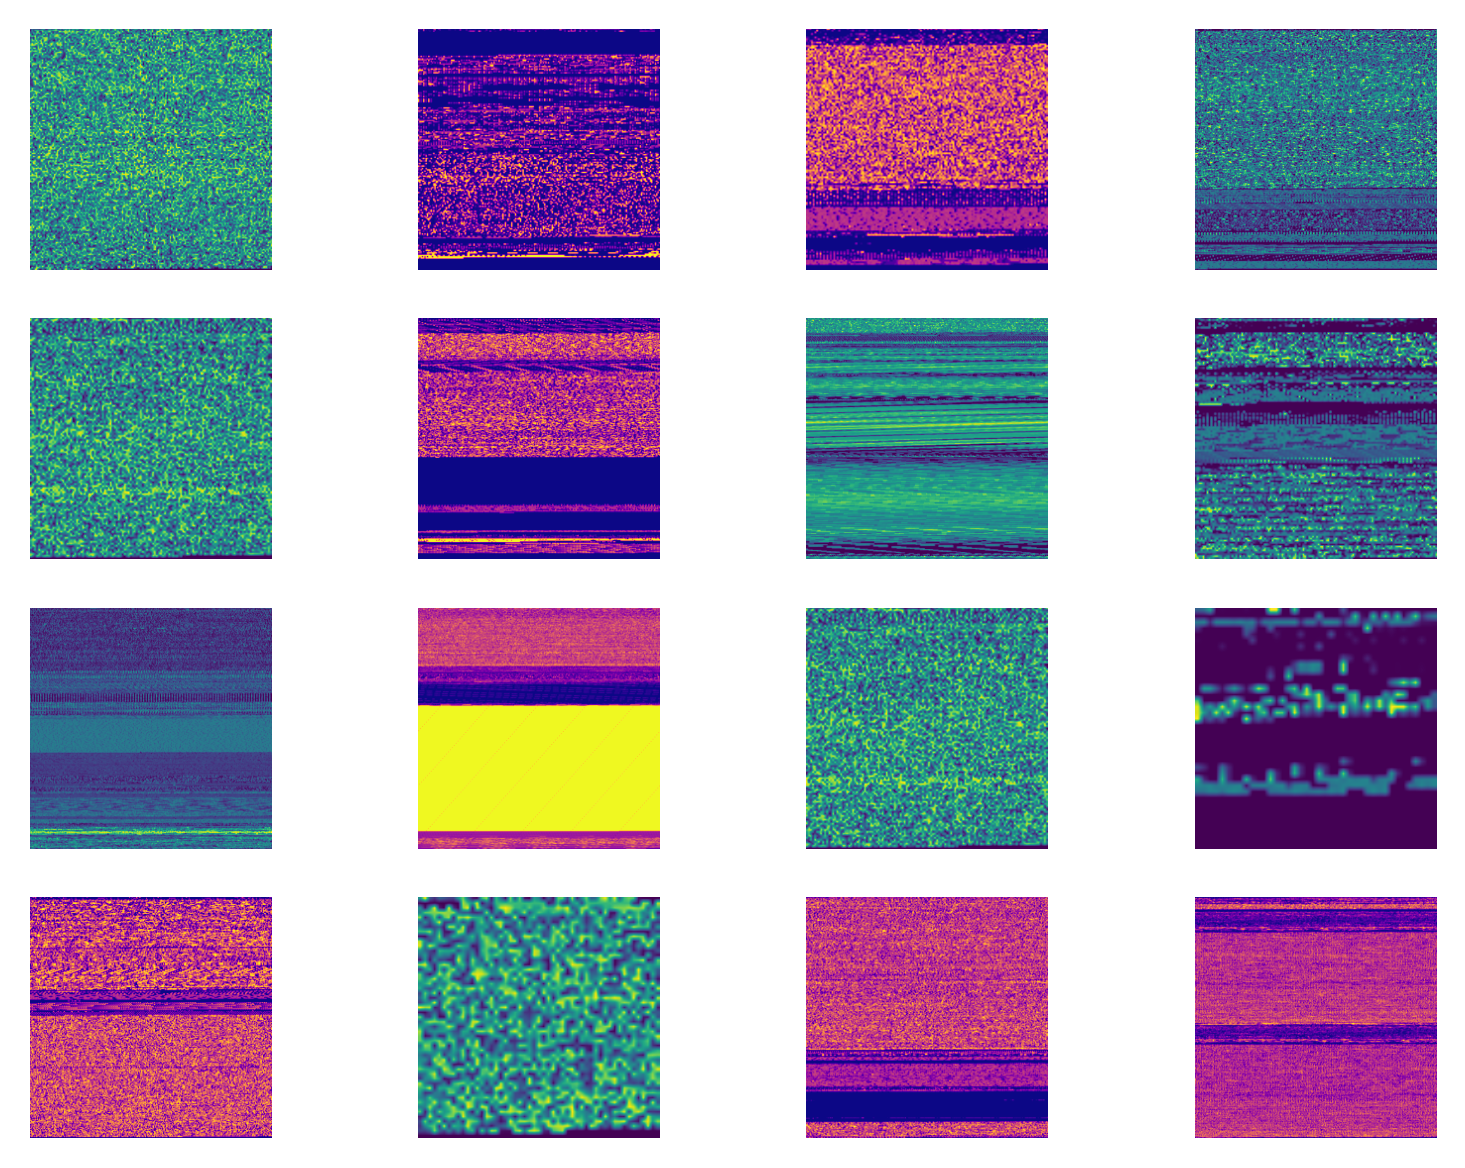

In [55]:
def make_image(file_path: PathLike) -> np.ndarray:
    binary = open(file_path, "rb").read()
    num_bytes = len(binary)
    shape = np.ceil(np.sqrt(num_bytes)).astype(np.int32)

    image = np.zeros((shape**2,))
    image[:num_bytes] = list(binary)
    image = torch.tensor(image).reshape((1, 1, shape, shape))
    return TF.resize(image, size=[244, 244])


idxs = np.random.choice(len(dataset), size=16)
plt.tight_layout()
for i, idx in enumerate(idxs):
    path, label = dataset[idx]
    plt.subplot(4, 4, i + 1)
    plt.imshow(
        make_image(path).reshape(244, 244), cmap="viridis" if label == 0 else "plasma"
    )
    plt.axis("off")

In [27]:
images = [make_image(path) for path, _ in tqdm(dataset)]

 74%|███████▎  | 8194/11115 [12:19<24:23,  2.00it/s]  